In [34]:
#Cargamos los datos
import pandas as pd
data = pd.read_excel("df_final_con_gravedad.xlsx")


In [35]:
data.head()

,num_expediente,dia_hora,distrito,tipo_accidente,estado_meteorológico,Conductores,Pasajeros,Peatones,Vehículo de dos ruedas,Vehículo pesado,Turismo,Otros vehículos,total_implicados,tiene_vulnerables,diversidad_vehiculos,franja_horaria,indice_gravedad,categoria_gravedad
0,2020S019534,2021-01-01 04:00:00,PUENTE DE VALLECAS,Colisión fronto-lateral,Despejado,3,2,0,0,0,3,0,5,0,1,Madrugada,3.7,Medio
1,2021S000001,2021-01-01 00:00:00,USERA,Colisión fronto-lateral,Despejado,2,3,0,0,0,2,0,5,0,1,Madrugada,3.7,Medio
2,2021S000003,2021-01-01 00:00:00,MORATALAZ,Colisión frontal,Lluvia débil,2,0,0,0,0,2,0,2,0,1,Madrugada,4.5,Medio
3,2021S000004,2021-01-01 01:00:00,SALAMANCA,Atropello a persona,Nublado,1,0,1,0,0,1,0,2,1,1,Madrugada,7.2,Alto
4,2021S000005,2021-01-01 01:00:00,PUENTE DE VALLECAS,Colisión fronto-lateral,Nublado,2,0,0,0,0,2,0,2,0,1,Madrugada,3.7,Medio


In [36]:
import pandas as pd

# Nos aseguramos que dia_hora está en formato datetime
data['dia_hora'] = pd.to_datetime(data['dia_hora'])

# Separar en dos columnas para luego hacer la clasificacion de franja horaria
data['fecha'] = data['dia_hora'].dt.date
data['hora'] = data['dia_hora'].dt.time

#Eliminamos columnas que no aporten informacion al modelo
#Eliminamos las features que no podamos saber antes del que se produzca un supuesto accidente
drop_columns = [
    'num_expediente',
    'dia_hora',
   # 'es_accidente',
    'tipo_accidente',
    "Peatones",
    "total_implicados",
    "diversidad_vehiculos",
    "categoria_gravedad"

]
data.drop(drop_columns, axis=1, inplace=True)

In [37]:
#La columna de estado meteorológico lo separamos en nuevas columnas de conteo de cada precipitación
data["Despejado"]=(data["estado_meteorológico"]=="Despejado").astype(int)
data["Lluvia débil"]=(data["estado_meteorológico"]=="Lluvia débil").astype(int)
data["Nublado"]=(data["estado_meteorológico"]=="Nublado").astype(int)
data["Lluvia intensa"]=(data["estado_meteorológico"]=="Lluvia intensa").astype(int)
data['Granizando']=(data["estado_meteorológico"]=='Granizando').astype(int)
data['Nevando']=(data["estado_meteorológico"]=='Nevando').astype(int)

data=data.drop(columns=["estado_meteorológico"])

In [38]:
# Agrupar por 'distrito', 'fecha' y 'franja_horaria'
# Luego, podemos aplicar funciones de agregación.
agrupacion_completa = data.groupby(['distrito', 'fecha', 'franja_horaria']).agg(
    #total_conductores=('Conductores', 'sum'), lo quitamos por que nunca sabremos de antemano el numero de conductores de un accidente
    total_pasajeros=('Pasajeros', 'median'), #Ponemos mediana para estimar el numero de pasajeros más frecuente.
    vehiculo_dos_ruedas=('Vehículo de dos ruedas', lambda x: int((x != 0).any())), #Si al final se usa la suma, cambia lambda por sum
    vehiculo_pesado=('Vehículo pesado', lambda x: int((x != 0).any())),
    turismo=('Turismo', lambda x: int((x != 0).any())),
    otros_vehiculos=('Otros vehículos', lambda x: int((x != 0).any())),
    tiene_vulnerables=('tiene_vulnerables', 'sum'),
    indice_gravedad=('indice_gravedad', 'mean'),#Voy aprobar con la media
    Despejado=('Despejado', 'sum'),
    Lluvia_débil=('Lluvia débil', 'sum'),
    Lluvia_intensa=('Lluvia intensa', 'sum'),
    Nublado=('Nublado', 'sum'),
    Granizo= ('Granizando', 'sum'),
    Nevando= ('Nevando', 'sum'),
   # dia_semana=('dia_semana', 'first'), esto lo dejo comentado por que estoy probando a ñadirlo despues
).reset_index()

In [39]:
agrupacion_completa.head()

,distrito,fecha,franja_horaria,total_pasajeros,vehiculo_dos_ruedas,vehiculo_pesado,turismo,otros_vehiculos,tiene_vulnerables,indice_gravedad,Despejado,Lluvia_débil,Lluvia_intensa,Nublado,Granizo,Nevando
0,ARGANZUELA,2021-01-01,Noche,1.0,0,0,1,0,0,3.000,1,0,0,0,0,0
1,ARGANZUELA,2021-01-02,Tarde,0.0,1,0,1,0,0,4.825,2,0,0,0,0,0
2,ARGANZUELA,2021-01-03,Tarde,0.0,1,0,1,0,0,4.950,1,0,0,0,0,0
3,ARGANZUELA,2021-01-04,Tarde,0.0,1,0,1,0,0,4.450,1,0,0,0,0,0
4,ARGANZUELA,2021-01-06,Noche,0.0,1,0,1,0,0,3.525,2,0,0,0,0,0


In [40]:
#Vamos a comprar el numero de filas esperado (nº distritos por las 4 franjas horarias y por todos los dias de año)
# Lo renombramos como df para simplificar
df = agrupacion_completa

# Valores únicos
distritos = df['distrito'].unique()
fechas = pd.date_range(start='2021-01-01', end='2024-12-31', freq='D')
franjas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']

# Total esperado
total_esperado = len(distritos) * len(fechas) * len(franjas)
print(f"Registros esperados: {total_esperado}")
print(f"Registros actuales: {len(df)}")


Registros esperados: 122724
Registros actuales: 54179


Se ve que faltan datos, seguramente de deba a un error en la generacion de las filas de no accidente

In [41]:
import itertools
#combinaciones['fecha'] = pd.to_datetime(combinaciones['fecha'])
df['fecha'] = pd.to_datetime(df['fecha'])
# Producto cartesiano de todas las combinaciones posibles
combinaciones = pd.DataFrame(itertools.product(distritos, fechas, franjas),
                             columns=['distrito', 'fecha', 'franja_horaria'])
df_completo = pd.merge(combinaciones, df,
                       on=['distrito', 'fecha', 'franja_horaria'],
                       how='left')
columnas_a_rellenar = [
    #'total_conductores',
    'total_pasajeros',
    'vehiculo_dos_ruedas',
    'vehiculo_pesado',
    'turismo', 'otros_vehiculos',
    "indice_gravedad",
    'Despejado', 'Lluvia_débil', 'Lluvia_intensa',
    'Nublado','Granizo', 'Nevando'
]

# Rellena NaNs con 0 en estas columnas
df_completo[columnas_a_rellenar] = df_completo[columnas_a_rellenar].fillna(0)
columnas_a_ajustar = [
    #'total_conductores',
    'total_pasajeros',
    'vehiculo_dos_ruedas',
    'vehiculo_pesado',
    "turismo",
    'otros_vehiculos',
    "tiene_vulnerables"
]

df_completo.loc[df_completo['indice_gravedad'] == 0, columnas_a_ajustar] = 0

df_completo.head()
print(f"Registros actuales: {len(df_completo)}")

Registros actuales: 122724


In [42]:


# Si no tienes el locale configurado en español, puedes traducir manualmente:
dias_esp = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df_completo['dia_semana'] = df_completo['fecha'].dt.day_name().map(dias_esp)

In [43]:
#La fecha la separamos en mes y dia, esto ya que el modelo no aprende de formato datetime
#Respecto al año, lo más lógico es eliminarlo, ya que el modelo va a predecir con un año distinto al de aprendizaje
# Asegúrate de que la columna 'fecha' es tipo datetime
df_completo["fecha"] = pd.to_datetime(df_completo["fecha"])

# Extrae año, mes y día
df_completo["mes"] = df_completo["fecha"].dt.month
df_completo["día"] = df_completo["fecha"].dt.day


#Ahora vamos a crear una columna llamada festivo, que nos dice si es un día festivo o no
!pip install holidays
import holidays

festivos = holidays.country_holidays('ES', subdiv='MD')
df_completo['es_festivo'] = df_completo['fecha'].dt.date.apply(lambda x: 1 if x in festivos else 0)

#ELiminamos fecha
df_completo=df_completo.drop(columns=["fecha"])

In [44]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122724 entries, 0 to 122723
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   distrito             122724 non-null  object 
 1   franja_horaria       122724 non-null  object 
 2   total_pasajeros      122724 non-null  float64
 3   vehiculo_dos_ruedas  122724 non-null  float64
 4   vehiculo_pesado      122724 non-null  float64
 5   turismo              122724 non-null  float64
 6   otros_vehiculos      122724 non-null  float64
 7   tiene_vulnerables    122724 non-null  float64
 8   indice_gravedad      122724 non-null  float64
 9   Despejado            122724 non-null  float64
 10  Lluvia_débil         122724 non-null  float64
 11  Lluvia_intensa       122724 non-null  float64
 12  Nublado              122724 non-null  float64
 13  Granizo              122724 non-null  float64
 14  Nevando              122724 non-null  float64
 15  dia_semana       

In [45]:

from sklearn.model_selection import train_test_split

# Detectar columnas categóricas automáticamente (dtype == object)
categorical_cols = df_completo.select_dtypes(include=['object']).columns.tolist()

# Si quieres eliminar la variable objetivo 'categoria_gravedad' de la codificación
if 'indice_gravedad' in categorical_cols:
    categorical_cols.remove('indice_gravedad')

# Aplicar One-Hot Encoding con pandas
data_encoded = pd.get_dummies(df_completo, columns=categorical_cols, drop_first=True)

In [46]:
X_data = data_encoded.drop("indice_gravedad", axis=1)
y_data = data_encoded["indice_gravedad"]

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42, shuffle= True)


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [49]:
!pip install xgboost
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convertir datos a DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'subsample': 0.8,
    'seed': 42
}

evals = [(dval, 'eval'), (dtrain, 'train')]

model_xb = xgb.train(params, dtrain, num_boost_round=100,
                  evals=evals,
                  early_stopping_rounds=10,
                  verbose_eval=True)

# Predicción
y_train_pred = model_xb.predict(dtrain)
y_val_pred = model_xb.predict(dval)

# Métricas
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

print(f"Train MSE: {mse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Val MSE: {mse_val:.4f}, MAE: {mae_val:.4f}")
print(f"Train R2: {r2_train:.4f}, Val R2: {r2_val:.4f}")


[0]	eval-rmse:1.52159	train-rmse:1.52197
[1]	eval-rmse:1.08612	train-rmse:1.08620
[2]	eval-rmse:0.78844	train-rmse:0.78802
[3]	eval-rmse:0.58861	train-rmse:0.58709
[4]	eval-rmse:0.45929	train-rmse:0.45643
[5]	eval-rmse:0.37822	train-rmse:0.37473
[6]	eval-rmse:0.32861	train-rmse:0.32452
[7]	eval-rmse:0.30052	train-rmse:0.29557
[8]	eval-rmse:0.28441	train-rmse:0.27870
[9]	eval-rmse:0.27504	train-rmse:0.26877
[10]	eval-rmse:0.26855	train-rmse:0.26209
[11]	eval-rmse:0.26471	train-rmse:0.25771
[12]	eval-rmse:0.26168	train-rmse:0.25419
[13]	eval-rmse:0.25998	train-rmse:0.25227
[14]	eval-rmse:0.25809	train-rmse:0.25019
[15]	eval-rmse:0.25724	train-rmse:0.24923
[16]	eval-rmse:0.25635	train-rmse:0.24786
[17]	eval-rmse:0.25548	train-rmse:0.24694
[18]	eval-rmse:0.25468	train-rmse:0.24575
[19]	eval-rmse:0.25428	train-rmse:0.24508
[20]	eval-rmse:0.25366	train-rmse:0.24437
[21]	eval-rmse:0.25323	train-rmse:0.24387
[22]	eval-rmse:0.25276	train-rmse:0.24308
[23]	eval-rmse:0.25245	train-rmse:0.24261
[2

                        Variable  Importancia
6                      Despejado   896.371460
3                        turismo   690.579285
1            vehiculo_dos_ruedas   220.511337
5              tiene_vulnerables   141.584854
2                vehiculo_pesado    52.712883
4                otros_vehiculos    13.032303
8                        Nublado     7.839318
36          franja_horaria_Tarde     5.615008
34         franja_horaria_Mañana     4.658177
37             dia_semana_Jueves     3.742782
39             dia_semana_Martes     3.491420
41             dia_semana_Sábado     3.363222
40          dia_semana_Miércoles     3.170880
7                   Lluvia_débil     2.842855
0                total_pasajeros     2.091009
10                       Nevando     1.693044
38              dia_semana_Lunes     1.653955
35          franja_horaria_Noche     1.097431
42            dia_semana_Viernes     0.971479
16               distrito_CENTRO     0.950753
18             distrito_CHAMBERÍ  

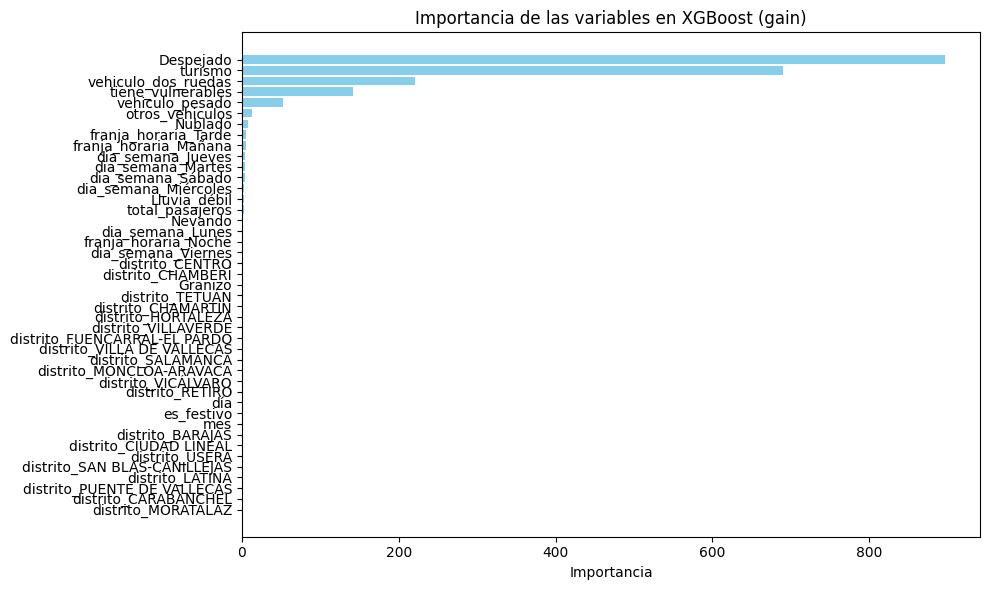

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Obtenemos importancias desde el Booster
scores = model_xb.get_score(importance_type='gain')  # también puedes usar 'weight' o 'cover'

# Convertimos a DataFrame
importancia_df = pd.DataFrame({
    'Variable': list(scores.keys()),
    'Importancia': list(scores.values())
}).sort_values(by='Importancia', ascending=False)

# Mostramos
print(importancia_df)

# Gráfico
plt.figure(figsize=(10,6))
plt.barh(importancia_df['Variable'], importancia_df['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.title('Importancia de las variables en XGBoost (gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



,distrito,predicción_Índice_Gravedad
10,CARABANCHEL,2.725711
18,VICÁLVARO,2.709800
0,CENTRO,2.708153
6,CHAMBERÍ,2.700465
15,HORTALEZA,2.693458
19,SAN BLAS-CANILLEJAS,2.679320
16,VILLAVERDE,2.678817
7,FUENCARRAL-EL PARDO,2.676603
1,ARGANZUELA,2.676603
20,BARAJAS,2.676603


/tmp/ipython-input-52-582183598.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred['distrito_norm'] = df_pred['distrito'].apply(normalizar_nombre)


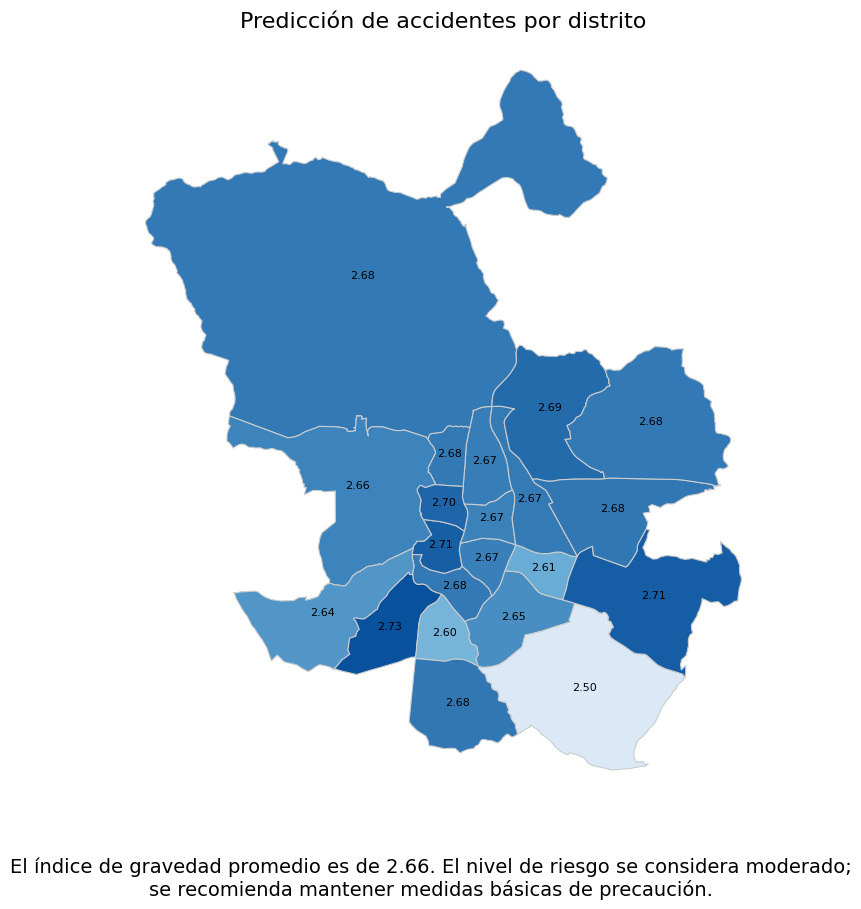

In [52]:
# --- IMPORTACIONES ---
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import unicodedata  # para normalizar y quitar tildes

# --- DATOS INICIALES ---

distritos = [
    'CENTRO', 'ARGANZUELA', 'RETIRO', 'SALAMANCA', 'CHAMARTÍN', 'TETUÁN',
    'CHAMBERÍ', 'FUENCARRAL-EL PARDO', 'MONCLOA-ARAVACA', 'LATINA', 'CARABANCHEL',
    'USERA', 'PUENTE DE VALLECAS', 'MORATALAZ', 'CIUDAD LINEAL', 'HORTALEZA',
    'VILLAVERDE', 'VILLA DE VALLECAS', 'VICÁLVARO', 'SAN BLAS-CANILLEJAS', 'BARAJAS'
]

franjas_horarias = ['Madrugada', 'Mañana', 'Tarde', 'Noche']

climas = ['Despejado', 'Lluvia_débil', 'Lluvia_intensa', 'Nublado', 'Granizo', 'Nevando']

dias_semana = [
    'Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'
]

# --- WIDGETS ---

franja_horaria = widgets.Dropdown(options=franjas_horarias, description='Franja:')
#conductores = widgets.FloatText(min=0, max=10, description='Conductores:', disabled=True)
pasajeros = widgets.FloatSlider(min=0, max=50, step=1, description='Pasajeros:')
vehiculo_dos_ruedas = widgets.FloatSlider(min=0, max=1, step=1, description='2 ruedas:')
vehiculo_pesado = widgets.FloatSlider(min=0, max=1, step=1, description='Pesados:')
turismo = widgets.FloatSlider(min=0, max=1, step=1, description='Turismos:')
otros_vehiculos = widgets.FloatSlider(min=0, max=1, step=1, description='Otros veh.:')
mes = widgets.IntSlider(min=1, max=12, description='Mes:')
dia = widgets.IntSlider(min=1, max=31, description='Día:')
es_festivo= widgets.Checkbox(value=False, description="Festivo")
dia_semana = widgets.Dropdown(options=dias_semana, description='Día de la semana:')
tiene_vulnerables = widgets.Checkbox(value=False, description='¿Vulnerables?')



clima_widgets = {clima: widgets.Checkbox(value=False, description=clima) for clima in climas}
boton = widgets.Button(description="Predecir accidentes por distrito")

inputs = widgets.VBox([
    franja_horaria,
    #conductores,
    pasajeros,
    vehiculo_dos_ruedas, vehiculo_pesado, turismo, otros_vehiculos,
    mes, dia, dia_semana, es_festivo, tiene_vulnerables,
    widgets.HTML(value="<b>Condiciones climáticas:</b>"),
    *clima_widgets.values(), boton
])

display(inputs)

# --- CARGAR DATOS GEOGRÁFICOS ---

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/madrid-districts.geojson"
gdf = gpd.read_file(url)
gdf.rename(columns={"name": "NOMBRE"}, inplace=True)

def normalizar_nombre(s):
    s = s.upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')  # quita tildes
    s = s.replace('-', ' ')
    s = s.strip()
    if s == "SAN BLAS CANILLEJAS":
        s = "SAN BLAS"
    return s

gdf["NOMBRE_norm"] = gdf["NOMBRE"].apply(normalizar_nombre)

# --- MOSTRAR MAPA ---

def mostrar_mapa(df_pred):
    df_pred['distrito_norm'] = df_pred['distrito'].apply(normalizar_nombre)
    df_merge = gdf.merge(df_pred, left_on='NOMBRE_norm', right_on='distrito_norm', how='left')

    min_pred = df_merge["predicción_Índice_Gravedad"].min()
    df_merge['escala_color'] = df_merge["predicción_Índice_Gravedad"] / (min_pred if min_pred != 0 else 1)

    cmap = LinearSegmentedColormap.from_list(
        "azul_madrid",
        ["#dbe9f6", "#6baed6", "#08519c"]
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    df_merge.plot(column='escala_color', cmap=cmap, linewidth=0.8, edgecolor='0.8', legend=False, ax=ax)

    # Añadir los valores predichos en el centro de cada polígono
    for idx, row in df_merge.iterrows():
        if pd.notnull(row["predicción_Índice_Gravedad"]):
            centroid = row["geometry"].centroid
            ax.text(centroid.x, centroid.y,
                    f'{row["predicción_Índice_Gravedad"]:.2f}',
                    horizontalalignment='center',
                    fontsize=8,
                    color='black')

    # Calcular la media y generar el mensaje
    media = df_merge["predicción_Índice_Gravedad"].mean()
    if 2 <= media < 3.5:
        mensaje = ("El nivel de riesgo se considera moderado;\n"
        "se recomienda mantener medidas básicas de precaución")
    elif 3.5 <= media < 5.5:
        mensaje = ("Se detecta un nivel de riesgo relevante;\n"
        "se aconseja aumentar la atención durante la conducción.")
    elif media >= 5.5:
        mensaje = ("El nivel de riesgo es elevado;\n"
        "se recomienda extremar las precauciones y evitar zonas de alta concentración vehicular")
    else:
        mensaje = ("El nivel de riesgo es bajo;\n"
        "no se requieren medidas adicionales.")

    # Añadir el texto debajo del mapa
    plt.figtext(0.5, 0.02,
                f"El índice de gravedad promedio es de {media:.2f}. {mensaje}.",
                ha='center', fontsize=14)

    ax.set_title("Predicción de accidentes por distrito", fontsize=16)
    ax.axis("off")
    plt.show()

feature_names = X_train.columns.tolist()  # variable global o en scope accesible

def on_button_clicked(b):
    rows = []
    for distrito in distritos:
        row = {
            'distrito': distrito,
            'total_pasajeros': pasajeros.value,
            'mes': mes.value,
            'dia': dia.value,
            'es_festivo': es_festivo.value,
            'dia_semana': dia_semana.value,
            'tiene_vulnerables': tiene_vulnerables.value,
            'franja_horaria': franja_horaria.value,
            'vehiculo_dos_ruedas': vehiculo_dos_ruedas.value,
            'vehiculo_pesado': vehiculo_pesado.value,
            'turismo': turismo.value,
            'otros_vehiculos': otros_vehiculos.value,
        }
        for clima in clima_widgets:
            row[clima] = int(clima_widgets[clima].value)
        rows.append(row)

    df_input = pd.DataFrame(rows)

    # One-hot encoding
    df_encoded = pd.get_dummies(df_input)

    # Añadir columnas faltantes con ceros
    for col in feature_names:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    # Reordenar columnas para coincidir con el entrenamiento
    df_encoded = df_encoded[feature_names]

    # Crear DMatrix para la predicción
    dmatrix_input = xgb.DMatrix(df_encoded, feature_names=feature_names)

    # Predecir con Booster
    df_input["predicción_Índice_Gravedad"] = model_xb.predict(dmatrix_input)

    # Mostrar resultados
    display(df_input[['distrito', "predicción_Índice_Gravedad"]].sort_values(by="predicción_Índice_Gravedad", ascending=False))
    mostrar_mapa(df_input[['distrito', "predicción_Índice_Gravedad"]])


# --- Conectar botón ---
boton.on_click(on_button_clicked)
